<a href="https://colab.research.google.com/github/srinivasrom/MyStore/blob/master/EDA_Assg_NYC_Taxi_Starter_Srinivas_Rompala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
import warnings
#!pip install numpy==1.26.4
import numpy as np
#!pip install pandas==2.2.3
import pandas as pd
#!pip install matplotlib==3.10.0
import matplotlib as plt
#!pip install seaborn==0.13.2
import seaborn as sns


In [2]:
# Import the libraries you will be using for analysis



In [3]:
#Recommended versions
#numpy version: 1.26.4
# pandas version: 2.2.3
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file
df = pd.read_parquet('yellow_tripdata_2023-12.parquet')
df.info()
df.count()
df.shape[0] #no of rows
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376567 entries, 0 to 3376566
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2023-12-01 00:06:06,2023-12-01 00:15:47,0.0,1.10,1.0,N,230,48,1,10.0,3.5,0.5,1.50,0.0,1.0,16.50,2.5,0.0
1,1,2023-12-01 00:22:26,2023-12-01 00:28:53,0.0,1.50,1.0,N,142,238,1,9.3,3.5,0.5,2.85,0.0,1.0,17.15,2.5,0.0
2,1,2023-12-01 00:59:44,2023-12-01 01:13:22,2.0,2.20,1.0,N,114,186,1,13.5,3.5,0.5,3.00,0.0,1.0,21.50,2.5,0.0
3,2,2023-12-01 00:22:17,2023-12-01 00:30:59,1.0,0.66,1.0,N,79,79,2,7.2,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0
4,2,2023-12-01 00:18:16,2023-12-01 00:25:32,2.0,2.20,1.0,N,229,263,1,11.4,1.0,0.5,2.00,0.0,1.0,18.40,2.5,0.0
5,1,2023-12-01 00:13:17,2023-12-01 00:23:53,0.0,5.70,1.0,N,88,141,1,23.3,3.5,0.5,0.00,0.0,1.0,28.30,2.5,0.0
6,2,2023-12-01 00:17:09,2023-12-01 00:33:31,1.0,5.33,1.0,N,45,162,1,24.7,1.0,0.5,3.00,0.0,1.0,32.70,2.5,0.0
7,2,2023-12-01 00:40:49,2023-12-01 00:44:10,1.0,0.76,1.0,N,170,107,1,5.8,1.0,0.5,1.00,0.0,1.0,11.80,2.5,0.0
8,2,2023-12-01 00:19:04,2023-12-01 00:34:36,1.0,3.33,1.0,N,186,209,1,17.7,1.0,0.5,3.40,0.0,1.0,26.10,2.5,0.0
9,1,2023-12-01 00:08:39,2023-12-01 00:16:18,1.0,2.10,1.0,N,163,262,1,12.1,3.5,0.5,3.42,0.0,1.0,20.52,2.5,0.0


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

In [5]:
# sampled_data is an empty DF to keep appending sampled data of each hour
sampled_data = pd.DataFrame()
# hour_data is the DF of entries for an hour 'X' on a date 'Y'
hour_data = df[df['tpep_pickup_datetime'].dt.hour == 12]

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
sampled_data.head()# printing first 5 default rows to check the data is correct or not

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
3205274,1,2023-12-03 12:57:18,2023-12-03 13:18:41,NaN,0.00,NaN,None,236,230,0,18.0,0.0,0.5,3.30,0.0,1.0,27.30,NaN,NaN
2044236,2,2023-12-18 12:51:07,2023-12-18 13:03:48,1.0,1.54,1.0,N,141,236,1,12.1,0.0,0.5,3.22,0.0,1.0,19.32,2.5,0.0
162792,2,2023-12-02 12:34:55,2023-12-02 12:46:52,1.0,1.80,1.0,N,144,107,1,12.8,0.0,0.5,3.36,0.0,1.0,20.16,2.5,0.0
1316791,1,2023-12-12 12:53:16,2023-12-12 13:06:27,1.0,1.50,1.0,N,100,264,1,13.5,2.5,0.5,3.50,0.0,1.0,21.00,2.5,0.0
2046285,2,2023-12-18 12:14:09,2023-12-18 12:22:41,1.0,0.93,1.0,N,230,161,2,9.3,0.0,0.5,0.00,0.0,1.0,13.30,2.5,0.0


---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [6]:
# Sample the data

# It is recommmended to not load all the files at once to avoid memory overload

In [7]:
#from google.colab import drive
#drive.mount('/content/drive/MyDrive/dataset/')
#df = pd.read_parquet(
 #   '/content/drive/MyDrive/dataset/yellow_tripdata_2023-12.parquet'
#)



In [8]:
import os
import pandas as pd

# Change to the directory containing the parquet files
os.chdir('/content')

# Create a list of all the twelve files to read
file_list = os.listdir()

# Initialise an empty dataframe to store the combined sampled data
df = pd.DataFrame()

# Iterate through the list of files and sample one by one:
for file_name in file_list:
    # Only process parquet files that are for yellow taxi data
    if not file_name.endswith('.parquet') or not file_name.startswith('yellow_tripdata_2023-'):
        continue

    try:
        # Construct the full file path
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current month's file
        current_month_df = pd.read_parquet(file_path)

        # Ensure 'tpep_pickup_datetime' is in datetime format for operations
        current_month_df['tpep_pickup_datetime'] = pd.to_datetime(current_month_df['tpep_pickup_datetime'])

        # Initialise an empty DataFrame to store sampled data for the current month
        sampled_month_data = pd.DataFrame()

        # Get unique dates in the current month's data
        unique_dates = current_month_df['tpep_pickup_datetime'].dt.date.unique()

        # Loop through each unique date
        for date in unique_dates:
            daily_data = current_month_df[current_month_df['tpep_pickup_datetime'].dt.date == date]
            # Iterate through each hour of the selected date (0 to 23)
            for hour in range(24):
                hour_data = daily_data[daily_data['tpep_pickup_datetime'].dt.hour == hour]

                # Sample 5% of the hourly data randomly
                if not hour_data.empty:
                    sample = hour_data.sample(frac=0.05, random_state=42)
                    # Add data of this hour to the sampled_month_data
                    sampled_month_data = pd.concat([sampled_month_data, sample], ignore_index=True)

        # Concatenate the sampled data of the current month to the main dataframe
        df = pd.concat([df, sampled_month_data], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# Display the first few rows of the final combined and sampled dataframe
display(df.head())
print(f"Total sampled rows: {len(df)}")
df.to_parquet('/content/NewDataFrame.parquet')


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00,NaN
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00,NaN
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00,NaN
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00,NaN
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75,NaN


Total sampled rows: 1915511


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [9]:
# Store the df in csv/parquet


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [10]:
# Load the new data file
df1=pd.read_parquet('/content/NewDataFrame.parquet')
df1.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915511 entries, 0 to 1915510
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [11]:
# df.head()
df1.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00,NaN
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00,NaN
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00,NaN
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00,NaN
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75,NaN


In [12]:
# df.info()
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915511 entries, 0 to 1915510
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

In [13]:
#Fix/drop any columns as you seem necessary in the below sections
df1.info()
df1.head()
df1.shape[0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915511 entries, 0 to 1915510
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

1915511

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [14]:
# Fix the index and drop any columns that are not needed
df1.reset_index(drop=True, inplace=True)
df1.head()
#drop any columns
df1.drop(columns=['PULocationID'],axis=1, inplace=True)
df1.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00,NaN
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00,NaN
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00,NaN
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00,NaN
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [15]:
# Combine the two airport fee columns
df1 = pd.read_parquet('/content/NewDataFrame.parquet')
df1.reset_index(drop=True, inplace=True)
df1['Airport_fee'] = df1['Airport_fee'].combine_first(df1['airport_fee'])
df1.drop(columns=['airport_fee'],axis=1, inplace=True)
df1.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [16]:
# check where values of fare amount are negative
df1.loc[df1['fare_amount'] < 0, 'fare_amount'].value_counts()


,count
fare_amount,
-3.00,2348
-70.00,1330
-7.20,750
-6.50,688
-5.80,672
...,...
-180.00,1
-111.90,1
-27.00,1


Did you notice something different in the `RatecodeID` column for above records?

In [17]:
# Analyse RatecodeID for the negative fare amounts

negative_fares = df1[df1['fare_amount'] < 0]
negative_fares
negative_fares[['fare_amount', 'RatecodeID']]

,fare_amount,RatecodeID
29,-3.0,1.0
50,-3.7,1.0
82,-11.4,1.0
108,-70.0,2.0
141,-17.7,1.0
...,...,...
1915217,-9.3,1.0
1915238,-70.0,2.0
1915346,-5.8,1.0
1915378,-22.6,1.0


In [18]:
# Find which columns have negative values
negetiv_Counts= df1.select_dtypes(include=['number']).lt(0).sum()
negetiv_Counts


,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,19056
extra,9472
mta_tax,18241


In [19]:
# fix these negative values
numeric_cols = df1.select_dtypes(include='number').columns
df1[numeric_cols] = df1[numeric_cols].clip(lower=0)
df1.head()
#negetiv_Counts= df1.select_dtypes(include=['number']).lt(0).sum()
#negetiv_Counts

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [20]:
# Find the proportion of missing values in each column
missing_values = df1.isnull().sum()
missing_proportion = missing_values / len(df1)
missing_proportion
missing_prop_new = df1.isnull().mean() * 100
missing_prop_new


,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,3.400659
trip_distance,0.000000
RatecodeID,3.400659
store_and_fwd_flag,3.400659
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [21]:
# Display the rows with null values
df1=pd.read_parquet('/content/NewDataFrame.parquet')
df1.reset_index(drop=True, inplace=True)
null_rows = df1[df1.isnull().any(axis=1)]

display(null_rows)
# Impute NaN values in 'passenger_count'


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.70,0.0,1.0,16.30,2.5,0.00,NaN
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.00,0.0,1.0,9.40,2.5,0.00,NaN
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.00,0.0,1.0,44.70,0.0,0.00,NaN
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.00,NaN
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.00,0.0,1.0,52.75,0.0,1.75,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915506,2,2023-09-30 23:11:08,2023-09-30 23:21:13,1.0,0.93,1.0,N,264,264,1,10.0,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.00,NaN
1915507,2,2023-09-30 23:48:57,2023-10-01 00:02:56,1.0,1.70,1.0,N,170,144,1,13.5,1.0,0.5,3.70,0.0,1.0,22.20,2.5,0.00,NaN
1915508,2,2023-09-30 23:42:26,2023-09-30 23:59:02,1.0,1.81,1.0,N,114,68,1,16.3,1.0,0.5,4.26,0.0,1.0,25.56,2.5,0.00,NaN
1915509,2,2023-09-30 23:19:02,2023-09-30 23:24:10,2.0,0.61,1.0,N,237,237,1,7.2,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.00,NaN


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [22]:
# Fix missing values in 'RatecodeID'
df1=pd.read_parquet('/content/NewDataFrame.parquet')
df1.reset_index(drop=True, inplace=True)
df1['RatecodeID'].fillna(0, inplace=True)
df1.head()


/tmp/ipykernel_7698/1897534628.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['RatecodeID'].fillna(0, inplace=True)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00,NaN
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00,NaN
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00,NaN
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00,NaN
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75,NaN


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [23]:
# handle null values in congestion_surcharge
df1['congestion_surcharge'].fillna(0, inplace=True)
df1.head()





/tmp/ipykernel_7698/3208516148.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['congestion_surcharge'].fillna(0, inplace=True)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00,NaN
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00,NaN
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00,NaN
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00,NaN
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75,NaN


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [24]:
# Handle any remaining missing values
df1.isnull().sum()
print('any null values',df1.isnull().values.any())
all_colms = df1.select_dtypes(include=['object', 'category']).columns

for col in all_colms:
    if df1[col].isnull().any():
        df1[col] = df1[col].fillna(df1[col].mode()[0])
df1.head()

any null values True


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00,NaN
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00,NaN
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00,NaN
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00,NaN
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75,NaN


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [25]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns



**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [26]:
# remove passenger_count > 6
df1 = df1[df1['passenger_count'] <= 6]
df1.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00,NaN
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00,NaN
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00,NaN
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00,NaN
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75,NaN


In [27]:
# Continue with outlier handling
df1 = df1[df1['trip_distance'] <= 250]
df1.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,8.6,3.5,0.5,2.7,0.0,1.0,16.30,2.5,0.00,NaN
1,1,2023-07-01 00:41:47,2023-07-01 00:44:30,2.0,0.40,1.0,N,107,234,3,4.4,3.5,0.5,0.0,0.0,1.0,9.40,2.5,0.00,NaN
2,2,2023-07-01 00:20:02,2023-07-01 00:46:03,2.0,10.42,1.0,N,132,72,2,42.2,1.0,0.5,0.0,0.0,1.0,44.70,0.0,0.00,NaN
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,10.0,1.0,0.5,3.0,0.0,1.0,18.00,2.5,0.00,NaN
4,2,2023-07-01 00:13:32,2023-07-01 00:52:21,1.0,9.43,1.0,N,132,198,2,48.5,1.0,0.5,0.0,0.0,1.0,52.75,0.0,1.75,NaN


In [28]:
# Do any columns need standardising?

df1.info()
df1.dtypes
df1.to_parquet('/content/NewDataFrame1.parquet')


<class 'pandas.core.frame.DataFrame'>
Index: 1850341 entries, 0 to 1915510
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            floa

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [29]:
df2 = pd.read_parquet('/content/NewDataFrame1.parquet')
df2.reset_index(drop=True, inplace=True)
df2.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [44]:
# Find and show the hourly trends in taxi pickups
df2['pickup_hour'] = df2['tpep_pickup_datetime'].dt.hour
hours = df2['pickup_hour'].value_counts().sort_index()
hours


,count
pickup_hour,
0,51935
1,34796
2,22987
3,14991
4,9673
5,10205
6,24709
7,49364
8,68796


In [45]:
# Find and show the daily trends in taxi pickups (days of the week)
df2['pickup_day'] = df2['tpep_pickup_datetime'].dt.dayofweek
days = df2['pickup_day'].value_counts().sort_index()
days


,count
pickup_day,
0,231542
1,268529
2,284205
3,290010
4,274623
5,268736
6,232696


In [46]:
# Show the monthly trends in pickups
df2['pickup_month'] = df2['tpep_pickup_datetime'].dt.month
months = df2['pickup_month'].value_counts().sort_index()
months


,count
pickup_month,
1,149811
2,141890
3,165769
4,159911
5,170507
6,160477
7,141119
8,136940
9,135366


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [51]:
# Analyse the above parameters

fare_amount_zero_or_negetive_count=(df['fare_amount'] <= 0).sum()
tip_amount_zero_or_negetive_count=(df['tip_amount'] <= 0).sum()
total_amount_zero_or_negetive_count=(df['total_amount'] <= 0).sum()
print(f"fare_amount_zero_or_negetive_count:{fare_amount_zero_or_negetive_count}")
print(f"tip_amount_zero_or_negetive_count:{tip_amount_zero_or_negetive_count}")
print(f"total_amount_zero_or_negetive_count:{total_amount_zero_or_negetive_count}")


fare_amount_zero_or_negetive_count:19723
tip_amount_zero_or_negetive_count:454050
total_amount_zero_or_negetive_count:19160


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [54]:
# Create a df with non zero entries for the selected parameters.

#df2 = df2[df2['fare_amount'] > 0]
#df2 = df2[df2['tip_amount'] > 0]
#df2 = df2[df2['total_amount'] > 0]
df_non_zero = df2[
    (df2['fare_amount'] > 0) &
    (df2['tip_amount'] > 0) &
    (df2['total_amount'] > 0) &
    (df2['trip_distance'] > 0)
]

display(df_non_zero.head())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee,pickup_hour,pickup_day,pickup_month
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,...,2.70,0.0,1.0,16.30,2.5,0.0,NaN,0,5,7
3,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,...,3.00,0.0,1.0,18.00,2.5,0.0,NaN,0,5,7
5,2,2023-07-01 00:45:37,2023-07-01 00:58:18,1.0,2.89,1.0,N,231,231,1,...,4.26,0.0,1.0,25.56,2.5,0.0,NaN,0,5,7
7,2,2023-07-01 00:15:21,2023-07-01 00:23:30,1.0,1.95,1.0,N,230,249,1,...,3.14,0.0,1.0,18.84,2.5,0.0,NaN,0,5,7
8,2,2023-07-01 00:55:04,2023-07-01 01:07:50,1.0,3.70,1.0,N,79,255,1,...,4.82,0.0,1.0,28.92,2.5,0.0,NaN,0,5,7


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [55]:
# Group data by month and analyse monthly revenue
df2['pickup_month'] = df2['tpep_pickup_datetime'].dt.month
monthly_revenue = df2.groupby('pickup_month')['total_amount'].sum()
monthly_revenue



,total_amount
pickup_month,
1,3253668.87
2,3100937.49
3,3723343.16
4,3612549.79
5,3958626.49
6,3712986.19
7,3145207.68
8,3035925.80
9,3232953.06


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [58]:
# Calculate proportion of each quarter
df2['pickup_quarterly'] = df2['tpep_pickup_datetime'].dt.quarter
quarter_revenue = df2.groupby('pickup_quarterly')['total_amount'].sum()
quarter_proportion = quarter_revenue / quarter_revenue.sum()
quarter_proportion



,total_amount
pickup_quarterly,
1,0.238708
2,0.267279
3,0.222984
4,0.271029


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

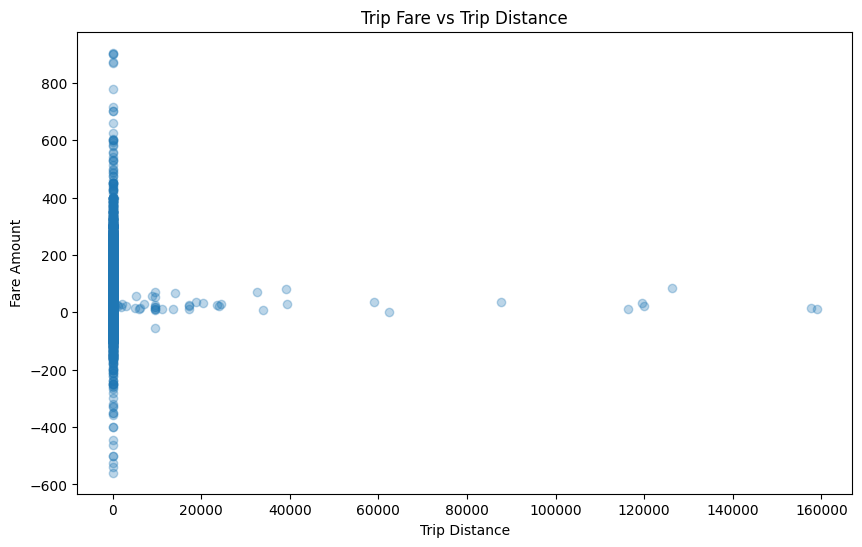

In [60]:
# Show how trip fare is affected by distance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.scatter(
    df['trip_distance'],
    df['fare_amount'],
    alpha=0.3
)

plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Trip Fare vs Trip Distance')

plt.show()



**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Text(0.5, 1.0, 'Fare Amount vs Trip Duration')

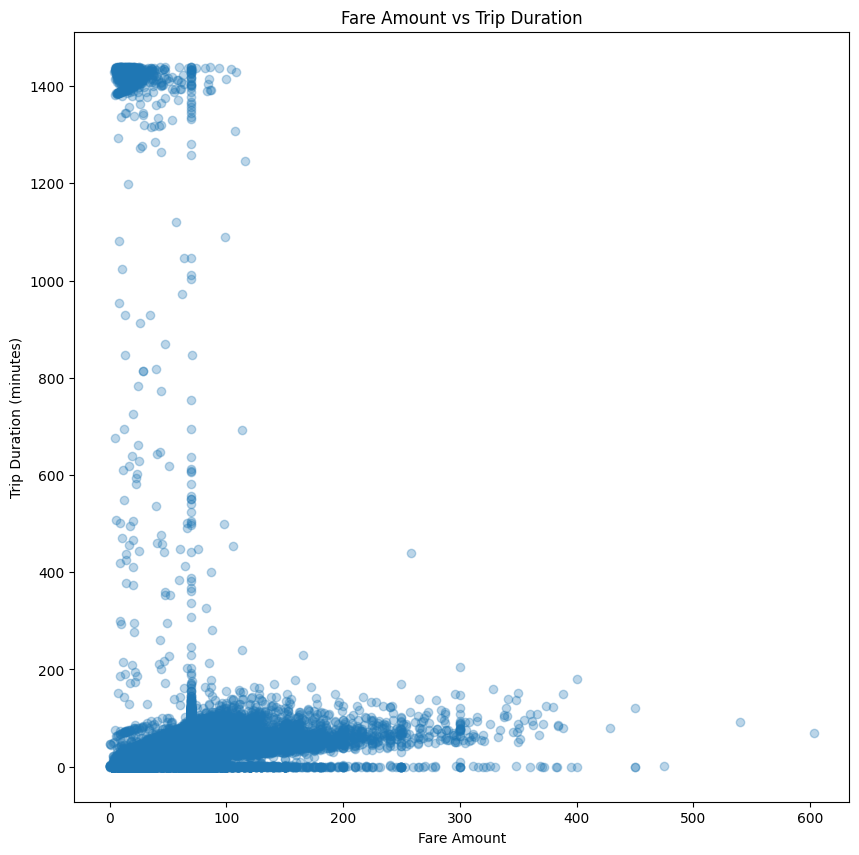

In [64]:
# Show relationship between fare and trip duration
plt.figure(figsize=(10,10))
df2['trip_duration'] = (df2['tpep_dropoff_datetime'] - df2['tpep_pickup_datetime']).dt.total_seconds() / 60
plot_df = df2[
    (df2['fare_amount'] > 0) &
    (df2['trip_duration'] > 0)
]
plt.scatter(
    plot_df['fare_amount'],
    plot_df['trip_duration'],
    alpha=0.3
)
plt.xlabel('Fare Amount')
plt.ylabel('Trip Duration (minutes)')
plt.title('Fare Amount vs Trip Duration')



Text(0.5, 1.0, 'Fare Amount vs Passenger_count')

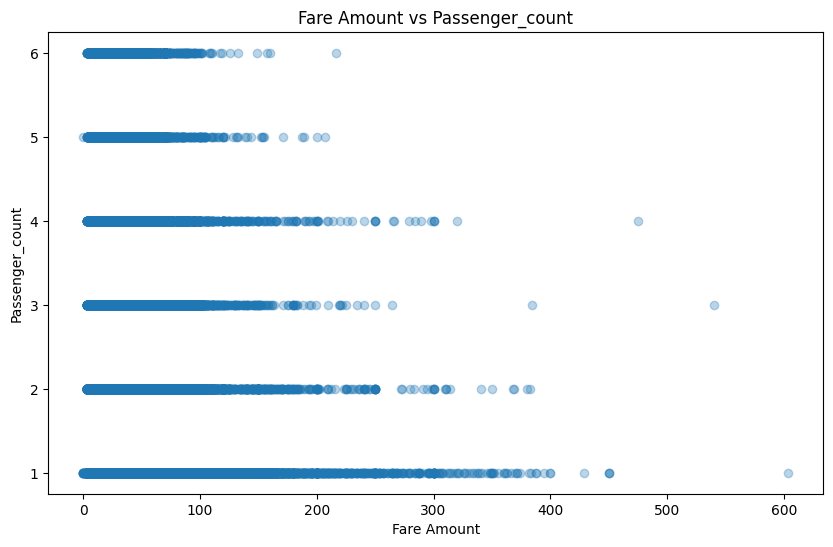

In [66]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(10,6))

plot_df = df2[(df2['fare_amount'] > 0) & (df2['passenger_count'] > 0)]
plt.scatter(
    plot_df['fare_amount'],
    plot_df['passenger_count'],
    alpha=0.3
)
plt.xlabel('Fare Amount')
plt.ylabel('Passenger_count')
plt.title('Fare Amount vs Passenger_count')


In [40]:
# Show relationship between tip and trip distance



**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [67]:
# Analyse the distribution of different payment types (payment_type).
df2['payment_type'].value_counts()




,count
payment_type,
1,1421534
3,76
2,27
4,15


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [68]:
# !pip install geopandas
!pip install geopandas
import geopandas as gpd

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [76]:

import geopandas as gpd
# Read the shapefile using geopandas
shape =  gpd.read_file('/content/taxi_zones.shp')
shape.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<Axes: >

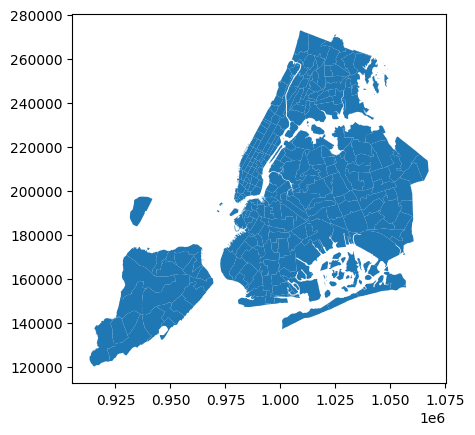

In [77]:
# print(zones.info())
# zones.plot()
shape.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [78]:
# Merge zones and trip records using locationID and PULocationID
shape = shape.rename(columns={'LocationID': 'PULocationID'})
df2 = df2.merge(shape, on='PULocationID', how='left')
df2.head()



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_month,pickup_quarter11,pickup_quarterly,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,borough,geometry
0,1,2023-07-01 00:36:53,2023-07-01 00:44:52,3.0,1.20,1.0,N,230,246,1,...,7,3,3,7.983333,230.0,0.031028,0.000056,Times Sq/Theatre District,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21..."
1,2,2023-07-01 00:50:54,2023-07-01 00:57:54,1.0,1.79,1.0,N,263,229,1,...,7,3,3,7.000000,263.0,0.037017,0.000066,Yorkville West,Manhattan,"POLYGON ((997493.323 220912.386, 997355.264 22..."
2,2,2023-07-01 00:45:37,2023-07-01 00:58:18,1.0,2.89,1.0,N,231,231,1,...,7,3,3,12.683333,231.0,0.063420,0.000167,TriBeCa/Civic Center,Manhattan,"POLYGON ((981667.364 203305, 981854.109 203130..."
3,2,2023-07-01 00:15:21,2023-07-01 00:23:30,1.0,1.95,1.0,N,230,249,1,...,7,3,3,8.150000,230.0,0.031028,0.000056,Times Sq/Theatre District,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21..."
4,2,2023-07-01 00:55:04,2023-07-01 01:07:50,1.0,3.70,1.0,N,79,255,1,...,7,3,3,12.766667,79.0,0.042625,0.000108,East Village,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [79]:
# Group data by location and calculate the number of trips
grouped_data = df2.groupby('PULocationID').size().reset_index(name='trip_count')
grouped_data.head()



,PULocationID,trip_count
0,1,125
1,3,1
2,4,1416
3,6,2
4,7,296


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [80]:
# Merge trip counts back to the zones GeoDataFrame
shape = shape.merge(grouped_data, on='PULocationID', how='left')
shape.head()




,OBJECTID,Shape_Leng,Shape_Area,zone,PULocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",125.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",1.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1416.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN


In [82]:
#from google.colab import sheets
#sheet = sheets.InteractiveSheet(df=shape)

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

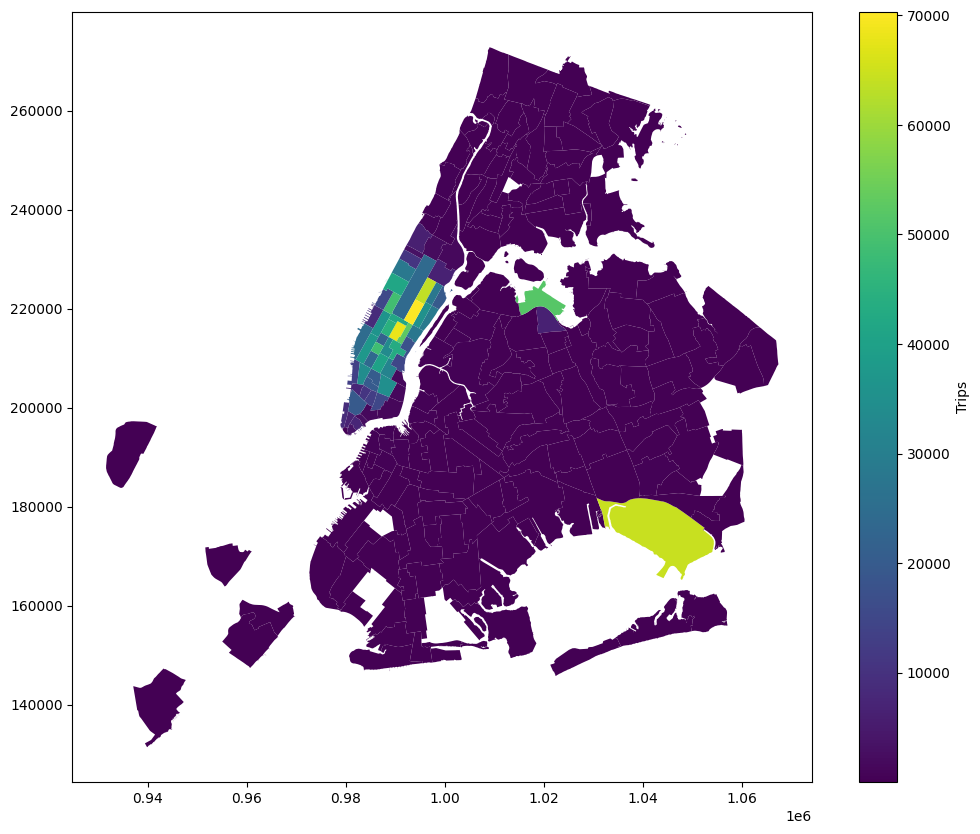

In [83]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))



# Plot the map and display it
shape.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Trips", 'orientation': "vertical"}
)
plt.show()



In [84]:
# can you try displaying the zones DF sorted by the number of trips?
shape.sort_values(by='trip_count', ascending=False)
shape



,OBJECTID,Shape_Leng,Shape_Area,zone,PULocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",125.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",1.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1416.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN
...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",1.0
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",106.0
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",6799.0
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",19610.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [88]:
# Find routes which have the slowest speeds at different times of the day
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] -
    df['tpep_pickup_datetime']
).dt.total_seconds() / 60
#removing invalid trips now
route_df = df[
    (df['trip_distance'] > 0) &
    (df['trip_duration'] > 0) &
    (df['PULocationID'].notna()) &
    (df['DOLocationID'].notna())
].copy()
route_df['pickup_hour'] = route_df['tpep_pickup_datetime'].dt.hour
route_analysis = (
    route_df
    .groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])
    .agg(
        avg_trip_duration=('trip_duration', 'mean'),
        avg_distance=('trip_distance', 'mean'),
        trip_count=('trip_duration', 'count')
    )
    .reset_index()
)
route_analysis


,PULocationID,DOLocationID,pickup_hour,avg_trip_duration,avg_distance,trip_count
0,1,1,5,0.341667,8.510000,2
1,1,1,8,0.283333,3.600000,1
2,1,1,10,0.075000,1.140000,2
3,1,1,11,0.366667,0.200000,1
4,1,1,13,12.777778,6.303333,3
...,...,...,...,...,...,...
134699,265,265,19,11.710256,9.776154,13
134700,265,265,20,5.266667,2.625000,12
134701,265,265,21,5.272917,3.788750,8
134702,265,265,22,11.705208,9.775625,16


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [89]:
# Visualise the number of trips per hour and find the busiest hour
df2['pickup_hour'] = df2['tpep_pickup_datetime'].dt.hour
hourly_trips = df2['pickup_hour'].value_counts().sort_index()
hourly_trips



,count
pickup_hour,
0,40313
1,26907
2,17428
3,10850
4,6240
5,6464
6,17614
7,38337
8,54435


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [91]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sampling_fraction = (
    df2.groupby('pickup_hour')
      .size()
      .sort_values(ascending=False)
      .head(5)
)

print(sampling_fraction)





pickup_hour
18    103659
17     97602
19     93053
16     87280
15     86164
dtype: int64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [93]:
# Compare traffic trends for the week days and weekends

df2['pickup_hour'] = df2['tpep_pickup_datetime'].dt.hour

df2['day_type'] = df['tpep_pickup_datetime'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)
hourly_traffic = df2.groupby(['pickup_hour', 'day_type']).size().unstack()
hourly_traffic

day_type,Weekday,Weekend
pickup_hour,,
0,29720,10593
1,19759,7148
2,12665,4763
3,7996,2854
4,4566,1674
5,4647,1817
6,12631,4983
7,27963,10374
8,39826,14609


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [95]:
# Find top 10 pickup and dropoff zones

top_pickup = df['PULocationID'].value_counts().head(10)
top_dropoff = df['DOLocationID'].value_counts().head(10)

print("Top 10 Pickup Zones:")
print(top_pickup)

print("\nTop 10 Drop-off Zones:")
print(top_dropoff)



Top 10 Pickup Zones:
PULocationID
132    99049
237    89667
161    88089
236    79943
162    67207
138    65140
186    65011
230    63228
142    62999
170    55935
Name: count, dtype: int64

Top 10 Drop-off Zones:
DOLocationID
236    84255
237    80310
161    74802
230    58883
170    56183
239    53666
162    53512
142    53361
141    50233
68     47951
Name: count, dtype: int64


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [97]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

pickup_counts = df['PULocationID'].value_counts()
dropoff_counts = df['DOLocationID'].value_counts()
ratio_df = pd.DataFrame({
    'pickup_count': pickup_counts,
    'dropoff_count': dropoff_counts
}).fillna(0)

ratio_df['pickup_dropoff_ratio'] = (
    ratio_df['pickup_count'] /
    ratio_df['dropoff_count']
)
top_10_ratio = (
    ratio_df
    .sort_values('pickup_dropoff_ratio', ascending=False)
    .head(10)
)

display(top_10_ratio)
bottom_10_ratio = (
    ratio_df
    .sort_values('pickup_dropoff_ratio', ascending=True)
    .head(10)
)

display(bottom_10_ratio)

,pickup_count,dropoff_count,pickup_dropoff_ratio
199,1.0,0.0,inf
105,1.0,0.0,inf
70,8663.0,1165.0,7.436052
132,99049.0,23944.0,4.136694
138,65140.0,24782.0,2.628521
186,65011.0,41583.0,1.563403
114,25318.0,18330.0,1.381233
43,31466.0,23307.0,1.350067
249,42720.0,31805.0,1.343185
162,67207.0,53512.0,1.255924


,pickup_count,dropoff_count,pickup_dropoff_ratio
204,0.0,8.0,0.000000
115,0.0,20.0,0.000000
99,0.0,2.0,0.000000
111,0.0,16.0,0.000000
245,1.0,25.0,0.040000
1,246.0,5891.0,0.041759
118,2.0,45.0,0.044444
206,2.0,41.0,0.048780
156,2.0,41.0,0.048780
27,2.0,41.0,0.048780


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [99]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

night_df = df[
    (df['pickup_hour'] >= 23) |
    (df['pickup_hour'] <= 5)
].copy()

top_10_night_pickups = (
    night_df['PULocationID']
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_night_pickups.columns = [
    'PULocationID',
    'pickup_count'
]

display(top_10_night_pickups)

top_10_night_dropoffs = (
    night_df['DOLocationID']
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_night_dropoffs.columns = [
    'DOLocationID',
    'dropoff_count'
]

display(top_10_night_dropoffs)

,PULocationID,pickup_count
0,79,16617
1,132,14837
2,249,13312
3,48,10945
4,148,10405
5,114,9279
6,230,8619
7,186,7220
8,164,6612
9,68,6483


,DOLocationID,dropoff_count
0,79,8857
1,48,7610
2,170,6525
3,68,6077
4,107,5967
5,141,5609
6,263,5440
7,249,5219
8,230,5023
9,148,4696


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [101]:
# Filter for night hours (11 PM to 5 AM)
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['time_period'] = df['pickup_hour'].apply(
    lambda x: 'Night' if x >= 23 or x <= 5 else 'Day'
)
revenue = (
    df.groupby('time_period')['total_amount']
      .sum()
      .sort_values(ascending=False)
)

print(revenue)

revenue_share = (
    revenue / revenue.sum() * 100
).round(2)

print(revenue_share)


time_period
Day      47675602.86
Night     6676385.43
Name: total_amount, dtype: float64
time_period
Day      87.72
Night    12.28
Name: total_amount, dtype: float64


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [103]:
# Analyse the fare per mile per passenger for different passenger counts

df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']

analysis_df = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['passenger_count'] > 0)
].copy()
fare_analysis = (
    analysis_df
    .groupby('passenger_count')
    .agg(
        avg_fare_per_mile=('fare_per_mile', 'mean')
    )
    .reset_index()
)
fare_analysis['fare_per_mile_per_passenger'] = (
    fare_analysis['avg_fare_per_mile'] /
    fare_analysis['passenger_count']
)
display(fare_analysis)


,passenger_count,avg_fare_per_mile,fare_per_mile_per_passenger
0,1.0,10.767553,10.767553
1,2.0,13.405013,6.702506
2,3.0,13.095632,4.365211
3,4.0,17.944844,4.486211
4,5.0,8.181261,1.636252
5,6.0,9.127078,1.521180
6,7.0,7200.000000,1028.571429
7,8.0,1885.197381,235.649673


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [105]:
# Compare the average fare per mile for different days and for different times of the day

df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']

df.groupby('pickup_hour')['fare_per_mile'].mean()

analysis_df = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0)
].copy()
hourly_fare = (
    analysis_df
    .groupby('pickup_hour')['fare_per_mile']
    .mean()
    .reset_index(name='avg_fare_per_mile')
)

display(hourly_fare)

,pickup_hour,avg_fare_per_mile
0,0,11.809521
1,1,10.076440
2,2,10.343693
3,3,11.237268
4,4,14.919353
5,5,14.372468
6,6,9.872804
7,7,10.022220
8,8,9.672648
9,9,11.104373


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [110]:
# Compare fare per mile for different vendors

df2['pickup_hour'] = df2['tpep_pickup_datetime'].dt.hour

df2['fare_per_mile'] = (
    df2['fare_amount'] / df2['trip_distance']
)
analysis_df = df2[
    (df2['trip_distance'] > 0) &
    (df2['fare_amount'] > 0)
].copy()
vendor_hourly_fare = (
    analysis_df
    .groupby(['VendorID', 'pickup_hour'])['fare_per_mile']
    .mean()
    .reset_index(name='avg_fare_per_mile')
)

display(vendor_hourly_fare)

,VendorID,pickup_hour,avg_fare_per_mile
0,1,0,6.652406
1,1,1,6.529506
2,1,2,6.707166
3,1,3,6.238355
4,1,4,7.488763
5,1,5,6.304104
6,1,6,6.483042
7,1,7,7.059753
8,1,8,7.898330
9,1,9,8.343169


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [113]:
# Defining distance tiers
analysis_df = df2[
    (df2['trip_distance'] > 0) &
    (df2['fare_amount'] > 0) &
    (df2['VendorID'].notna())
].copy()
analysis_df['distance_tier'] = pd.cut(
    analysis_df['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=['0-2', '2-5', '5+']
)

analysis_df['fare_per_mile'] = (
    analysis_df['fare_amount'] /
    analysis_df['trip_distance']
)
vendor_tier = (
    analysis_df
    .groupby(['VendorID', 'distance_tier'], observed=True)
    .agg(
        avg_fare_per_mile=('fare_per_mile', 'mean'),
        trip_count=('fare_amount', 'count')
    )
    .reset_index()
)

display(vendor_tier)

,VendorID,distance_tier,avg_fare_per_mile,trip_count
0,1,0-2,9.496437,210333
1,1,2-5,6.370262,98094
2,1,5+,4.471551,52578
3,2,0-2,13.875139,571821
4,2,2-5,6.544505,298975
5,2,5+,4.509300,181519


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

,distance_tier,avg_tip_percentage,trip_count
0,Up to 2 miles,22.438075,988057
1,2 to 5 miles,18.750330,482809
2,More than 5 miles,17.221132,308654


,passenger_count,avg_tip_percentage,trip_count
0,1.0,20.699427,1359417
1,2.0,19.771583,274978
2,3.0,19.024723,68073
3,4.0,17.412496,37704
4,5.0,29.149653,23525
5,6.0,20.548711,15816
6,7.0,0.000000,1
7,8.0,9.877648,6


,pickup_hour,avg_tip_percentage,trip_count
0,0,20.550862,49898
1,1,20.825058,33298
2,2,20.578122,21903
3,3,20.042955,14189
4,4,17.805770,9014
5,5,17.540616,9568
6,6,18.370594,23663
7,7,19.692091,47459
8,8,20.052149,66295
9,9,19.668979,75688


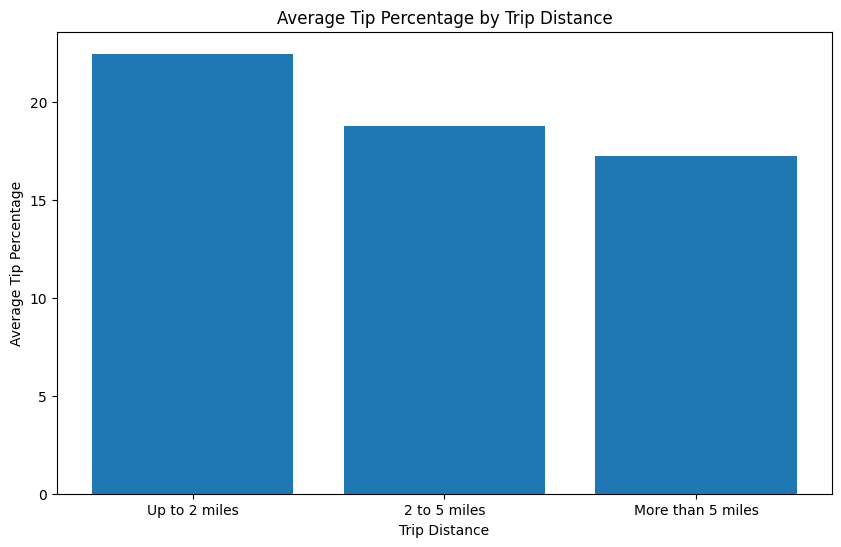

In [114]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
analysis_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['passenger_count'] > 0) &
    (df['tip_amount'] >= 0)
].copy()

analysis_df['tip_percentage'] = (
    analysis_df['tip_amount'] /
    analysis_df['fare_amount']
) * 100

analysis_df['pickup_hour'] = (
    analysis_df['tpep_pickup_datetime'].dt.hour
)
analysis_df['distance_tier'] = pd.cut(
    analysis_df['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=[
        'Up to 2 miles',
        '2 to 5 miles',
        'More than 5 miles'
    ],
    include_lowest=True
)
distance_tip = (
    analysis_df
    .groupby('distance_tier', observed=True)
    .agg(
        avg_tip_percentage=('tip_percentage', 'mean'),
        trip_count=('tip_percentage', 'count')
    )
    .reset_index()
)

display(distance_tip)
passenger_tip = (
    analysis_df
    .groupby('passenger_count')
    .agg(
        avg_tip_percentage=('tip_percentage', 'mean'),
        trip_count=('tip_percentage', 'count')
    )
    .reset_index()
)

display(passenger_tip)
hourly_tip = (
    analysis_df
    .groupby('pickup_hour')
    .agg(
        avg_tip_percentage=('tip_percentage', 'mean'),
        trip_count=('tip_percentage', 'count')
    )
    .reset_index()
)

display(hourly_tip)


plt.figure(figsize=(10, 6))

plt.bar(
    distance_tip['distance_tier'].astype(str),
    distance_tip['avg_tip_percentage']
)

plt.xlabel('Trip Distance')
plt.ylabel('Average Tip Percentage')
plt.title('Average Tip Percentage by Trip Distance')

plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

,pickup_hour,avg_passenger_count
0,0,1.408049
1,1,1.430682
2,2,1.429156
3,3,1.436937
4,4,1.386230
5,5,1.284609
6,6,1.240874
7,7,1.258022
8,8,1.272759
9,9,1.293892


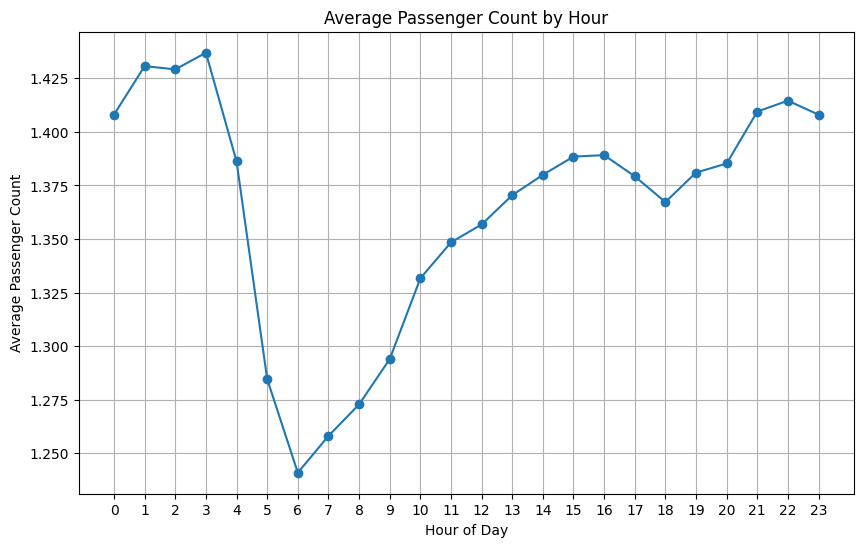

In [115]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
hourly_passengers = (
    df.groupby('pickup_hour')['passenger_count']
      .mean()
      .reset_index(name='avg_passenger_count')
)

display(hourly_passengers)

plt.figure(figsize=(10, 6))

plt.plot(
    hourly_passengers['pickup_hour'],
    hourly_passengers['avg_passenger_count'],
    marker='o'
)

plt.xlabel('Hour of Day')
plt.ylabel('Average Passenger Count')
plt.title('Average Passenger Count by Hour')
plt.xticks(range(24))
plt.grid(True)

plt.show()


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

,pickup_hour,avg_passenger_count
0,0,1.408049
1,1,1.430682
2,2,1.429156
3,3,1.436937
4,4,1.386230
5,5,1.284609
6,6,1.240874
7,7,1.258022
8,8,1.272759
9,9,1.293892


,day_of_week,avg_passenger_count
0,Monday,1.344198
1,Tuesday,1.315555
2,Wednesday,1.316708
3,Thursday,1.327634
4,Friday,1.382946
5,Saturday,1.462620
6,Sunday,1.445909


pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,1.382929,1.413828,1.377251,1.433518,1.345223,1.275168,1.222761,1.273531,1.289594,1.287944,...,1.362177,1.379706,1.373408,1.357070,1.335512,1.352764,1.361888,1.368500,1.372399,1.350859
Tuesday,1.339838,1.371936,1.403734,1.434211,1.314332,1.250330,1.229720,1.241617,1.244196,1.251346,...,1.339994,1.355291,1.338918,1.326107,1.310496,1.318234,1.326265,1.357104,1.357251,1.345331
Wednesday,1.358402,1.351226,1.417359,1.417722,1.329132,1.257772,1.214534,1.241317,1.251122,1.251048,...,1.318330,1.338732,1.338532,1.327129,1.311735,1.322688,1.330983,1.349336,1.368585,1.349403
Thursday,1.333620,1.354827,1.363273,1.355346,1.314118,1.270389,1.225149,1.260588,1.249824,1.260927,...,1.331010,1.354886,1.344280,1.326464,1.332364,1.331444,1.348137,1.384368,1.385314,1.355676
Friday,1.373394,1.369444,1.382309,1.365544,1.366125,1.282797,1.226723,1.246595,1.261853,1.300967,...,1.381950,1.384236,1.385241,1.391906,1.393289,1.425679,1.436571,1.487241,1.480957,1.465500
Saturday,1.438144,1.455975,1.457817,1.444714,1.404120,1.333333,1.301297,1.267554,1.349639,1.383351,...,1.473159,1.468695,1.491087,1.500178,1.481882,1.497933,1.502228,1.512538,1.494694,1.503093
Sunday,1.476984,1.479317,1.440872,1.467411,1.438184,1.343750,1.356206,1.330142,1.369406,1.406565,...,1.473559,1.454583,1.469300,1.458473,1.447421,1.442883,1.425131,1.434682,1.428905,1.400417


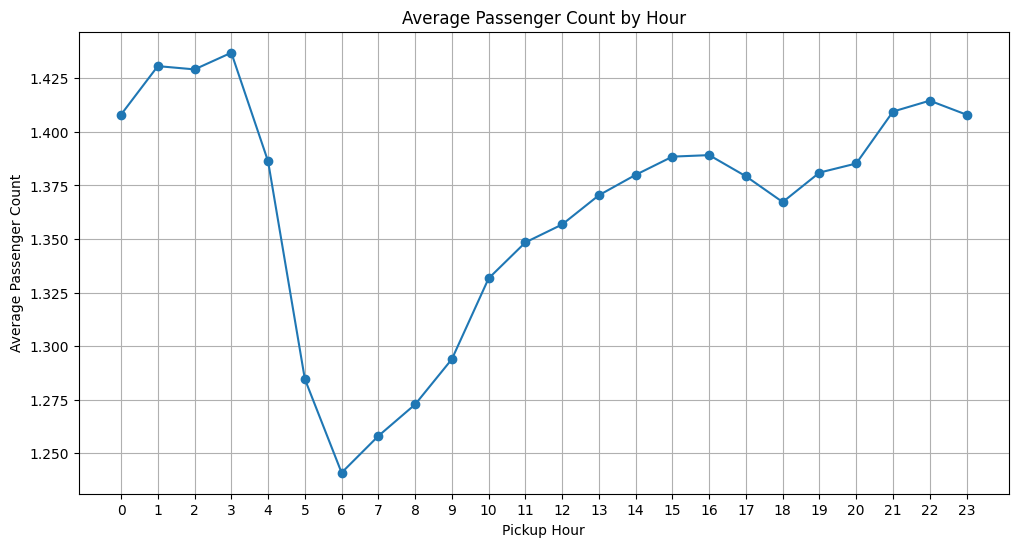

In [117]:
# See how passenger count varies across hours and days

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
hourly_passenger = (
    df.groupby('pickup_hour')['passenger_count']
      .mean()
      .reset_index(name='avg_passenger_count')
)

display(hourly_passenger)
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_passenger = (
    df.groupby('day_of_week')['passenger_count']
      .mean()
      .reindex(day_order)
      .reset_index(name='avg_passenger_count')
)

display(daily_passenger)
hour_day_passenger = (
    df.groupby(['day_of_week', 'pickup_hour'])['passenger_count']
      .mean()
      .unstack()
      .reindex(day_order)
)

display(hour_day_passenger)
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_passenger['pickup_hour'],
    hourly_passenger['avg_passenger_count'],
    marker='o'
)

plt.xlabel('Pickup Hour')
plt.ylabel('Average Passenger Count')
plt.title('Average Passenger Count by Hour')
plt.xticks(range(24))
plt.grid(True)

plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [119]:
# How does passenger count vary across zones

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['has_extra'] = df['extra'] > 0
extra_summary = df['has_extra'].value_counts(normalize=True) * 100

print(extra_summary)
hourly_extra = (
    df.groupby('pickup_hour')
      .agg(
          total_trips=('extra', 'size'),
          trips_with_extra=('has_extra', 'sum')
      )
      .reset_index()
)

hourly_extra['extra_charge_rate'] = (
    hourly_extra['trips_with_extra'] /
    hourly_extra['total_trips'] * 100
)

display(
    hourly_extra.sort_values(
        'extra_charge_rate',
        ascending=False
    )
)
top_hours = (
    hourly_extra
    .sort_values('extra_charge_rate', ascending=False)
    .head(5)
)

display(top_hours)

has_extra
True     59.454161
False    40.545839
Name: proportion, dtype: float64


,pickup_hour,total_trips,trips_with_extra,extra_charge_rate
21,21,107552,100260,93.220024
22,22,99715,91973,92.235872
20,20,107673,99220,92.149378
2,2,24174,22056,91.238521
23,23,79082,72137,91.217976
1,1,36565,33258,90.955832
0,0,54421,49211,90.426490
3,3,15993,14141,88.419934
4,4,10885,8487,77.969683
18,18,135216,104801,77.506360


,pickup_hour,total_trips,trips_with_extra,extra_charge_rate
21,21,107552,100260,93.220024
22,22,99715,91973,92.235872
20,20,107673,99220,92.149378
2,2,24174,22056,91.238521
23,23,79082,72137,91.217976


In [124]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
avg_passengers = (
    df.groupby('PULocationID')['passenger_count']
      .mean()
      .reset_index(name='avg_passenger_count')
)
zones_with_trips = shape.merge(
    avg_passengers,
    on='PULocationID',
    how='left'
)
display(
    zones_with_trips[
        ['PULocationID', 'zone', 'borough',
         'trip_count', 'avg_passenger_count']
    ].head(10)
)


,PULocationID,zone,borough,trip_count,avg_passenger_count
0,1,Newark Airport,EWR,125.0,1.626016
1,2,Jamaica Bay,Queens,NaN,1.000000
2,3,Allerton/Pelham Gardens,Bronx,1.0,1.000000
3,4,Alphabet City,Manhattan,1416.0,1.405478
4,5,Arden Heights,Staten Island,NaN,1.000000
5,6,Arrochar/Fort Wadsworth,Staten Island,2.0,2.083333
6,7,Astoria,Queens,296.0,1.271413
7,8,Astoria Park,Queens,4.0,1.333333
8,9,Auburndale,Queens,1.0,1.000000
9,10,Baisley Park,Queens,305.0,1.469027


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

,pickup_hour,total_trips,trips_with_extra,extra_charge_rate
21,21,107552,100260,93.220024
22,22,99715,91973,92.235872
20,20,107673,99220,92.149378
2,2,24174,22056,91.238521
23,23,79082,72137,91.217976
1,1,36565,33258,90.955832
0,0,54421,49211,90.426490
3,3,15993,14141,88.419934
4,4,10885,8487,77.969683
18,18,135216,104801,77.506360


,PULocationID,total_trips,trips_with_extra,extra_charge_rate
237,245,1,1,100.000000
131,138,65140,63687,97.769420
69,70,8663,7069,81.599908
141,148,20076,15548,77.445706
108,114,25318,19202,75.843274
78,79,45336,32862,72.485442
241,249,42720,30881,72.286985
137,144,17225,11902,69.097242
151,158,16997,11462,67.435430
213,221,3,2,66.666667


,DOLocationID,total_trips,trips_with_extra,extra_charge_rate
133,138,24782,21684,87.498991
39,40,1666,1312,78.751501
200,206,41,32,78.048780
53,54,426,331,77.699531
251,257,858,659,76.806527
176,181,4969,3792,76.313141
250,256,4244,3230,76.107446
79,80,2437,1848,75.830940
184,189,1731,1312,75.794339
51,52,1230,931,75.691057


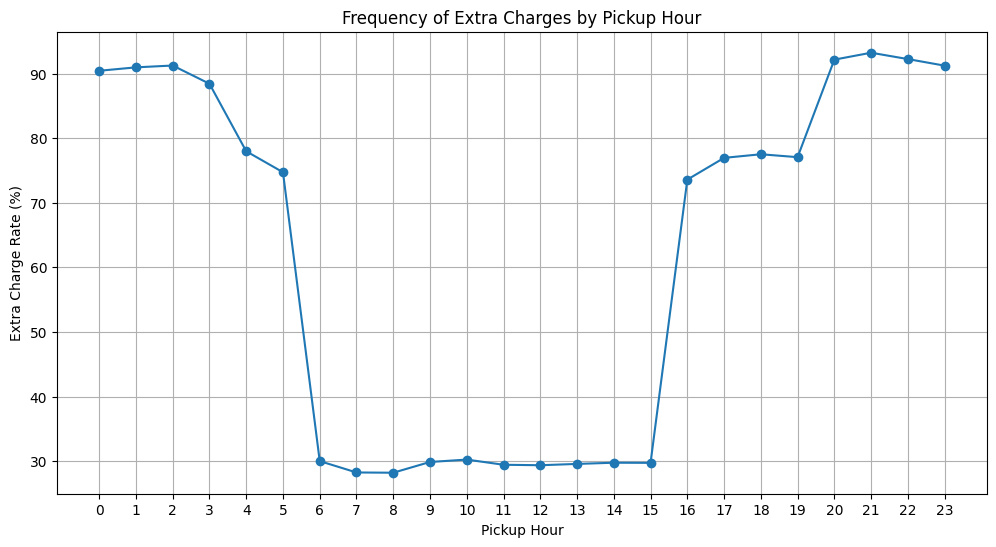

In [127]:
# How often is each surcharge applied?
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

df['has_extra'] = df['extra'] > 0
hourly_extra = (
    df.groupby('pickup_hour')
      .agg(
          total_trips=('extra', 'size'),
          trips_with_extra=('has_extra', 'sum')
      )
      .reset_index()
)

hourly_extra['extra_charge_rate'] = (
    hourly_extra['trips_with_extra'] /
    hourly_extra['total_trips'] * 100
)

display(
    hourly_extra.sort_values(
        'extra_charge_rate',
        ascending=False
    )
)
pickup_extra = (
    df.groupby('PULocationID')
      .agg(
          total_trips=('extra', 'size'),
          trips_with_extra=('has_extra', 'sum')
      )
      .reset_index()
)

pickup_extra['extra_charge_rate'] = (
    pickup_extra['trips_with_extra'] /
    pickup_extra['total_trips'] * 100
)
top_pickup_extra = (
    pickup_extra
    .sort_values('extra_charge_rate', ascending=False)
    .head(10)
)

display(top_pickup_extra)
dropoff_extra = (
    df.groupby('DOLocationID')
      .agg(
          total_trips=('extra', 'size'),
          trips_with_extra=('has_extra', 'sum')
      )
      .reset_index()
)

dropoff_extra['extra_charge_rate'] = (
    dropoff_extra['trips_with_extra'] /
    dropoff_extra['total_trips'] * 100
)

display(
    dropoff_extra
    .sort_values('extra_charge_rate', ascending=False)
    .head(10)
)

zone_hour_extra = (
    df.groupby(['PULocationID', 'pickup_hour'])
      .agg(
          total_trips=('extra', 'size'),
          trips_with_extra=('has_extra', 'sum')
      )
      .reset_index()
)

zone_hour_extra['extra_charge_rate'] = (
    zone_hour_extra['trips_with_extra'] /
    zone_hour_extra['total_trips'] * 100
)
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_extra['pickup_hour'],
    hourly_extra['extra_charge_rate'],
    marker='o'
)

plt.xlabel('Pickup Hour')
plt.ylabel('Extra Charge Rate (%)')
plt.title('Frequency of Extra Charges by Pickup Hour')
plt.xticks(range(24))
plt.grid(True)

plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.